# ANALISIS KESESUAIAN LOKASI FITNESS CENTER BERDASARKAN AKSESIBILITAS DAN KEPADATAN PENDUDUK USIA PRODUKTIF
**Studi Kasus:** Kawasan Perkotaan Yogyakarta  
**Metode:** Multi-Criteria Decision Analysis (MCDA) - Analytic Hierarchy Process (AHP) Berbasis Grid Spasial  
**Analis:** Clisen Ardy Laksono Wicaksono | 23/517152/SV/22742

---

## 1. Pendahuluan Eksekutif
Pemilihan lokasi komersial (*site selection*) untuk fasilitas *fitness center* bertaraf premium di Kota Yogyakarta menghadapi tantangan kompleksitas tata ruang. Analisis ini memanfaatkan pendekatan **Multi-Criteria Decision Analysis (MCDA)** untuk menyeimbangkan faktor pendorong (*benefit*) dan faktor penghambat (*cost*) bisnis secara presisi. 

Sistem beroperasi pada unit analisis grid spasial beresolusi **100x100 meter** dengan proyeksi metrik absolut **UTM Zone 49S (EPSG:32749)**. 

**Parameter Analisis:**
1. **Aksesibilitas Jaringan Jalan:** Jarak Euclidean terdekat menuju jalan arteri/kolektor (Faktor Pendorong).
2. **Kawasan Pendidikan:** Jarak dari kampus/universitas sebagai proksi segmentasi pasar usia produktif (Faktor Pendorong).
3. **Kepadatan Penduduk Aktual:** Kepadatan penduduk per kilometer persegi di tingkat kecamatan (Faktor Pendorong). Data tabular bersumber dari [Badan Pusat Statistik Kota Yogyakarta: Kepadatan Penduduk Menurut Kecamatan 2026](https://jogjakota.bps.go.id/id/statistics-table/3/V1ZSbFRUY3lTbFpEYTNsVWNGcDZjek53YkhsNFFUMDkjMyMzNDcx/jumlah-penduduk--laju-pertumbuhan-penduduk--distribusi-persentase-penduduk--kepadatan-penduduk--rasio-jenis-kelamin-penduduk-menurut-kecamatan-di-kota-yogyakarta.html?year=2026).
4. **Kejenuhan Kompetitor:** Jarak dari *fitness center* eksisting (Faktor Penghambat). Data titik lokasi bersumber dari [Dataset Fitness Center](https://github.com/Clis3n/23-517152-SV-22742_Clisen-Ardy-Laksono-Wicaksono_GitHub/blob/main/Fitness_Center.csv) hasil *scraping* Google Maps yang telah melalui tahap perapian data (*data cleaning*).

In [1]:
# ==============================================================================
# 1. PERSIAPAN LINGKUNGAN KERJA & INSTALASI PUSTAKA
# ==============================================================================
try:
    import google.colab
    IN_COLAB = True
    print("[SYSTEM] Lingkungan Google Colab terdeteksi. Mengunduh dependensi spasial...")
    !pip install -q geopandas osmnx contextily mapclassify matplotlib-scalebar adjustText
except ImportError:
    IN_COLAB = False
    print("[SYSTEM] Lingkungan lokal terdeteksi.")

import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import box, Point
import osmnx as ox

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import matplotlib.patches as patches
import matplotlib.patheffects as pe 
from mpl_toolkits.axes_grid1.inset_locator import inset_axes 
import mapclassify
import contextily as cx

try:
    from adjustText import adjust_text
except ImportError:
    print("[SYSTEM] Menginstal adjustText untuk engine label spasial...")
    os.system("pip install adjustText")
    from adjustText import adjust_text

ox.settings.log_console = False
ox.settings.use_cache = True

if not os.path.exists("output"):
    os.makedirs("output")

print("[SYSTEM] Seluruh pustaka dimuat.")

[SYSTEM] Lingkungan lokal terdeteksi.
[SYSTEM] Seluruh pustaka dimuat.


## 2. Ingesti Data (BPS, Repositori Daring, & OSM API)
Demi menjamin prinsip *one-click reproducibility* murni berbasis komputasi awan, seluruh basis data dikonfigurasi secara dinamis. Data kepadatan penduduk BPS diinjeksikan secara statis. Data sebaran *fitness center* dibaca melalui tautan *raw* repositori GitHub. Data spasial batas administrasi, jaringan jalan, dan kawasan kampus diekstraksi secara *live* dari OpenStreetMap via *Overpass API*.

In [2]:
# ==============================================================================
# 2. INGESTI DATA BPS (TABULAR), GOOGLE MAPS (CSV), & OSMNX (SPASIAL)
# ==============================================================================
KOTA = "Kota Yogyakarta, Daerah Istimewa Yogyakarta, Indonesia"
CRS_UTM = "EPSG:32749"

print("[PROSES] Mengunduh poligon batas Administratif & Kecamatan (OSM)...")
gdf_yogya = ox.geocode_to_gdf(KOTA)
gdf_yogya_utm = gdf_yogya.to_crs(CRS_UTM)

kecamatan_osm = ox.features_from_polygon(gdf_yogya.geometry.iloc[0], tags={'admin_level': ['6', '7']}) 
kecamatan_utm = kecamatan_osm.to_crs(CRS_UTM)
kecamatan_utm['nama_bersih'] = kecamatan_utm['name'].str.lower().str.replace(' ', '')

print("[PROSES] Mengintegrasikan Data Tabular Kota Yogyakarta 2026 (BPS)...")
data_bps = {
    'Kecamatan': ['Mantrijeron', 'Kraton', 'Mergangsan', 'Umbulharjo', 'Kotagede', 'Gondokusuman', 
                  'Danurejan', 'Pakualaman', 'Gondomanan', 'Ngampilan', 'Wirobrajan', 'Gedong Tengen', 
                  'Jetis', 'Tegalrejo'],
    'Kepadatan_Penduduk_Km2': [12648, 13091, 12551, 8215, 11258, 9293, 17076, 14197, 11241, 18334, 14019, 16788, 13636, 11747]
}
df_bps = pd.DataFrame(data_bps)
df_bps['Kec_Clean'] = df_bps['Kecamatan'].str.lower().str.replace(' ', '')

gdf_kecamatan_bps = kecamatan_utm.merge(df_bps, left_on='nama_bersih', right_on='Kec_Clean', how='left')

print("[PROSES] Menarik data titik kompetitor dari repositori GitHub (CSV)...")
URL_FITNESS = "https://raw.githubusercontent.com/Clis3n/23-517152-SV-22742_Clisen-Ardy-Laksono-Wicaksono_GitHub/refs/heads/main/Fitness_Center.csv"

df_fitness = pd.read_csv(URL_FITNESS, sep=';', encoding='utf-8-sig')

def clean_coordinate(val):
    val = str(val).replace('.', '')
    if ',' in val:
        val = val.split(',')[0]
    if val.startswith('-'):
        return float(val[:2] + '.' + val[2:])
    else:
        return float(val[:3] + '.' + val[3:])

df_fitness['Latitude'] = df_fitness['Latitude'].apply(clean_coordinate)
df_fitness['Longitude'] = df_fitness['Longitude'].apply(clean_coordinate)

df_fitness['geometry'] = [Point(lon, lat) for lon, lat in zip(df_fitness['Longitude'], df_fitness['Latitude'])]
gdf_fitness_raw = gpd.GeoDataFrame(df_fitness, geometry='geometry', crs='EPSG:4326').to_crs(CRS_UTM)

fitness_centroid = gpd.sjoin(gdf_fitness_raw, gdf_yogya_utm[['geometry']], how="inner", predicate="intersects")
fitness_centroid = fitness_centroid[['Nama Tempat', 'geometry']].copy()

print("[PROSES] Mengunduh infrastruktur jaringan jalan dan kawasan pendidikan (OSM)...")
tags_jalan = {'highway': ['primary', 'secondary', 'tertiary']}
jalan_osm = ox.features_from_polygon(gdf_yogya.geometry.iloc[0], tags=tags_jalan)
jalan_utm = jalan_osm[jalan_osm.geometry.type.isin(['LineString', 'MultiLineString'])].to_crs(CRS_UTM)

tags_kampus = {'amenity': ['university', 'college']}
kampus_osm = ox.features_from_polygon(gdf_yogya.geometry.iloc[0], tags=tags_kampus)
kampus_utm = kampus_osm.to_crs(CRS_UTM)

print("[STATUS] Seluruh data spasial berhasil diakuisisi dan diproyeksikan ke UTM 49S.")

[PROSES] Mengunduh poligon batas Administratif & Kecamatan (OSM)...
[PROSES] Mengintegrasikan Data Tabular Kota Yogyakarta 2026 (BPS)...
[PROSES] Menarik data titik kompetitor dari repositori GitHub (CSV)...
[PROSES] Mengunduh infrastruktur jaringan jalan dan kawasan pendidikan (OSM)...
[STATUS] Seluruh data spasial berhasil diakuisisi dan diproyeksikan ke UTM 49S.


## 3. Fabrikasi Unit Analisis Spasial (Grid 100x100m)
Kawasan administrasi dipecah menjadi mosaik jaring kotak berukuran **100x100 meter**. Arsitektur grid ini mendistribusikan bobot kalkulasi secara merata dan mereduksi ketidakakuratan spasial (*sliver polygons*) yang diakibatkan oleh *overlay* vektor tak beraturan.

In [3]:
# ==============================================================================
# 3. PEMBUATAN UNIT GRID ANALISIS SPASIAL
# ==============================================================================
print("[PROSES] Membangun jaring grid spasial beresolusi 100x100 meter...")

minx, miny, maxx, maxy = gdf_yogya_utm.total_bounds
cell_size = 100 

grid_cells = []
for x0 in np.arange(minx, maxx, cell_size):
    for y0 in np.arange(miny, maxy, cell_size):
        x1 = x0 + cell_size
        y1 = y0 + cell_size
        grid_cells.append(box(x0, y0, x1, y1))

gdf_grid_full = gpd.GeoDataFrame(geometry=grid_cells, crs=CRS_UTM)

gdf_grid = gpd.sjoin(gdf_grid_full, gdf_yogya_utm[['geometry']], how="inner", predicate="intersects")
gdf_grid = gdf_grid[['geometry']].copy()

gdf_grid['grid_id'] = range(len(gdf_grid))
gdf_grid['centroid'] = gdf_grid.geometry.centroid

print(f"[STATUS] Fabrikasi selesai. Tercipta matriks {len(gdf_grid)} sel grid analisis yang valid.")

[PROSES] Membangun jaring grid spasial beresolusi 100x100 meter...
[STATUS] Fabrikasi selesai. Tercipta matriks 3544 sel grid analisis yang valid.


## 4. Ekstraksi Parametrik (Jarak Euclidean & Kepadatan Penduduk)
Kalkulasi jarak spasial (*proximity*) ditarik dari titik pusat (*centroid*) masing-masing unit grid menuju fitur fisik terdekat. Parameter kepadatan demografi diinterpolasi dengan memindahkan nilai agregat BPS dari poligon batas kecamatan ke unit sel grid di dalamnya melalui metode *Spatial Join*.

In [4]:
# ==============================================================================
# 4. KALKULASI PARAMETER SPASIAL (PROXIMITY & DENSITY)
# ==============================================================================
print("[PROSES] Mengalkulasi jarak Euclidean menuju Jalan, Kampus, dan Kompetitor...")

gdf_centroids = gpd.GeoDataFrame(geometry=gdf_grid['centroid'], crs=CRS_UTM)

jalan_terdekat = gpd.sjoin_nearest(gdf_centroids, jalan_utm, how='left', distance_col='dist_jalan')
gdf_grid['dist_jalan'] = jalan_terdekat['dist_jalan'].groupby(jalan_terdekat.index).first()

kampus_terdekat = gpd.sjoin_nearest(gdf_centroids, kampus_utm, how='left', distance_col='dist_kampus')
gdf_grid['dist_kampus'] = kampus_terdekat['dist_kampus'].groupby(kampus_terdekat.index).first()

fitness_terdekat = gpd.sjoin_nearest(gdf_centroids, fitness_centroid, how='left', distance_col='dist_kompetitor')
gdf_grid['dist_kompetitor'] = fitness_terdekat['dist_kompetitor'].groupby(fitness_terdekat.index).first()

print("[PROSES] Mengatribusikan data Kepadatan Penduduk BPS ke dalam matriks grid...")

grid_bps = gpd.sjoin(gdf_centroids, gdf_kecamatan_bps[['geometry', 'Kepadatan_Penduduk_Km2']], how='left', predicate='within')
gdf_grid['kepadatan_penduduk'] = grid_bps['Kepadatan_Penduduk_Km2'].groupby(grid_bps.index).first()
gdf_grid['kepadatan_penduduk'] = gdf_grid['kepadatan_penduduk'].fillna(gdf_grid['kepadatan_penduduk'].mean())

print("[STATUS] Ekstraksi parameter keruangan dan demografi telah lengkap.")

[PROSES] Mengalkulasi jarak Euclidean menuju Jalan, Kampus, dan Kompetitor...
[PROSES] Mengatribusikan data Kepadatan Penduduk BPS ke dalam matriks grid...
[STATUS] Ekstraksi parameter keruangan dan demografi telah lengkap.


## 5. Standardisasi Parameter & Analytic Hierarchy Process (AHP)
Metrik berdimensi jamak disetarakan menggunakan algoritma *Min-Max Scaling* ke dalam rentang **Skor 1 (Terburuk) hingga 5 (Terbaik)**. Matriks hierarki keputusan dikalkulasi secara empiris menggunakan *Numpy Eigenvector* untuk mendistribusikan bobot prioritas. *Consistency Ratio* digunakan sebagai tolok ukur validitas logika matematis.

In [5]:
# ==============================================================================
# 5. STANDARDISASI KESESUAIAN & ALGORITMA AHP
# ==============================================================================
print("[PROSES] Menstandardisasi rentang metrik menjadi skor kesesuaian 1 - 5...")

def min_max_scale(series, criteria_type):
    min_val, max_val = series.min(), series.max()
    if min_val == max_val: return pd.Series([5]*len(series)) 
    scaled = 1 + 4 * ((series - min_val) / (max_val - min_val))
    
    if criteria_type == 'distance_benefit':
        return 6 - scaled 
    elif criteria_type == 'distance_cost':
        return scaled
    elif criteria_type == 'density_benefit':
        return scaled

gdf_grid['skor_jalan'] = min_max_scale(gdf_grid['dist_jalan'], 'distance_benefit')
gdf_grid['skor_kampus'] = min_max_scale(gdf_grid['dist_kampus'], 'distance_benefit')
gdf_grid['skor_kompetitor'] = min_max_scale(gdf_grid['dist_kompetitor'], 'distance_cost')
gdf_grid['skor_kepadatan'] = min_max_scale(gdf_grid['kepadatan_penduduk'], 'density_benefit') 

print("[PROSES] Mengoperasikan matriks dekomposisi AHP...")

ahp_matrix = np.array([
    [1.00,  1.00,  2.00,  3.00], 
    [1.00,  1.00,  2.00,  3.00], 
    [0.50,  0.50,  1.00,  2.00], 
    [0.33,  0.33,  0.50,  1.00]  
])

eigval, eigvec = np.linalg.eig(ahp_matrix)
max_eigval = np.max(np.real(eigval))
weights = np.real(eigvec[:, np.argmax(np.real(eigval))])
weights = weights / np.sum(weights) 

n = len(ahp_matrix)
RI = [0, 0, 0.58, 0.9, 1.12, 1.24, 1.32, 1.41, 1.45, 1.49] 
CI = (max_eigval - n) / (n - 1)
CR = CI / RI[n-1]

print("-" * 50)
print(f"Rasio Konsistensi (CR): {CR:.4f} (Syarat Validitas: < 0.1)")
print(f"Bobot Jaringan Jalan  : {weights[0]*100:.2f}%")
print(f"Bobot Kawasan Kampus  : {weights[1]*100:.2f}%")
print(f"Bobot Area Kepadatan  : {weights[2]*100:.2f}%")
print(f"Bobot Jarak Kompetitor: {weights[3]*100:.2f}%")
print("-" * 50)

print("[PROSES] Mengeksekusi Weighted Overlay untuk Skor Kesesuaian Akhir...")
gdf_grid['skor_akhir'] = (gdf_grid['skor_jalan'] * weights[0]) + \
                         (gdf_grid['skor_kampus'] * weights[1]) + \
                         (gdf_grid['skor_kepadatan'] * weights[2]) + \
                         (gdf_grid['skor_kompetitor'] * weights[3])

print("[STATUS] Modul matematis MCDA-AHP tuntas dikalkulasikan.")

[PROSES] Menstandardisasi rentang metrik menjadi skor kesesuaian 1 - 5...
[PROSES] Mengoperasikan matriks dekomposisi AHP...
--------------------------------------------------
Rasio Konsistensi (CR): 0.0018 (Syarat Validitas: < 0.1)
Bobot Jaringan Jalan  : 35.11%
Bobot Kawasan Kampus  : 35.11%
Bobot Area Kepadatan  : 18.91%
Bobot Jarak Kompetitor: 10.86%
--------------------------------------------------
[PROSES] Mengeksekusi Weighted Overlay untuk Skor Kesesuaian Akhir...
[STATUS] Modul matematis MCDA-AHP tuntas dikalkulasikan.


## 6. Pemetaan dan Simbologi Standar Jurnal
Hasil *Weighted Overlay* didiskritisasi mengadopsi standar **Natural Breaks (Fisher-Jenks)** ke dalam 5 kelas kesesuaian lahan. Peta final dieksekusi dengan tata letak komprehensif, mengintegrasikan Peta Inset, Distribusi Luasan, Arah Utara Poligonal, Garis Skala Numerik, dan Ekspor Resolusi Tinggi (300 dpi).

[PROSES] Merender tata letak kartografi akhir...
[STATUS] Layout kartografi selesai diekspor ke: output/Peta_Kesesuaian_Layout_Yogyakarta.png (300 dpi).


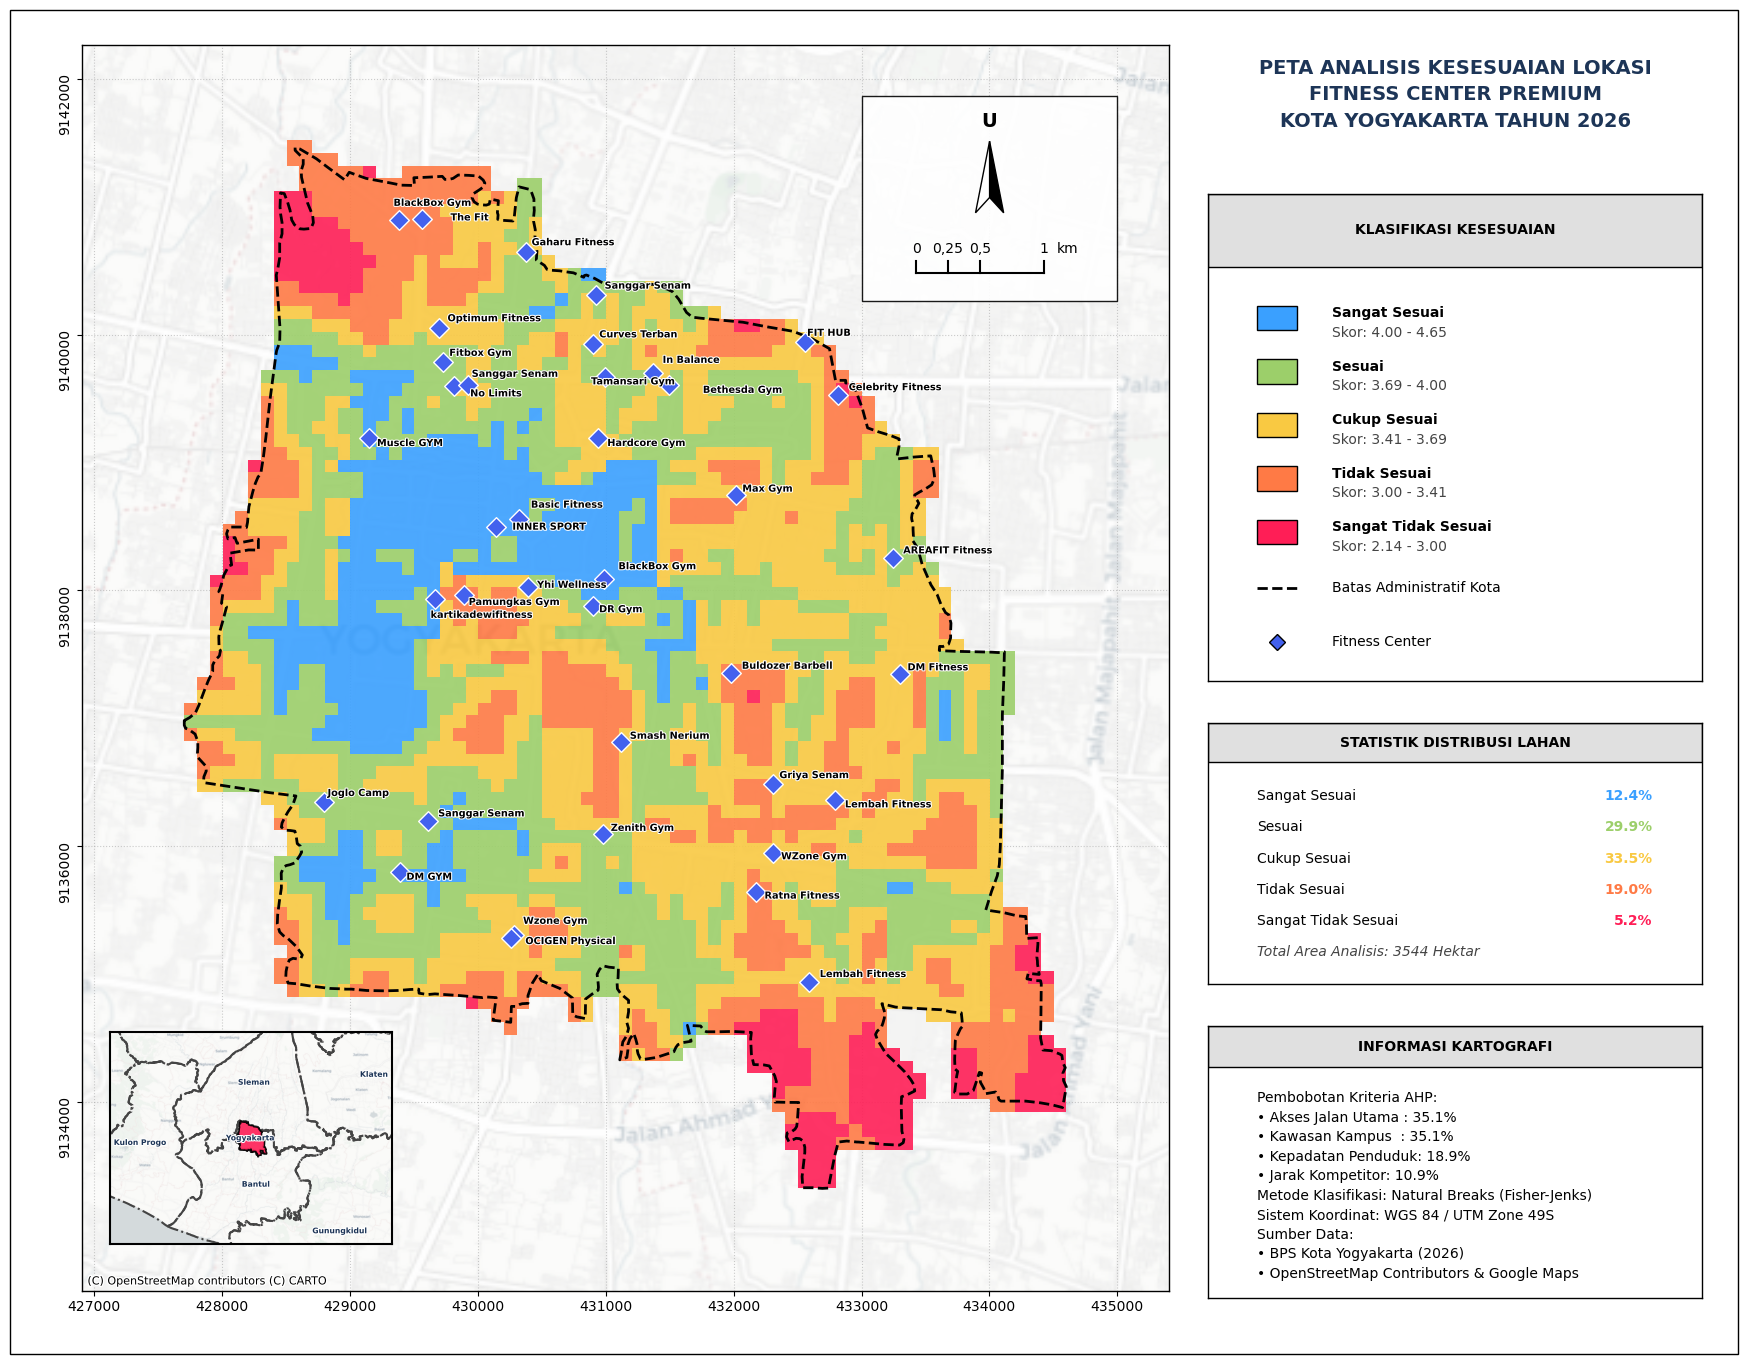

In [6]:
# ==============================================================================
# 6. KARTOGRAFI VISUAL LAYOUT
# ==============================================================================
print("[PROSES] Merender tata letak kartografi akhir...")

custom_colors = ['#ff1e56', '#ff7a45', '#f9c942', '#9ccf6a', '#3aa0ff']
custom_cmap = mcolors.ListedColormap(custom_colors) 

classifier = mapclassify.NaturalBreaks(gdf_grid['skor_akhir'], k=5)
gdf_grid['kelas_kesesuaian'] = classifier.find_bin(gdf_grid['skor_akhir'])

luas_ha = gdf_grid.groupby('kelas_kesesuaian').size() * 1
total_ha = luas_ha.sum()
pct_ha = (luas_ha / total_ha) * 100

kelas_labels = ["Sangat Tidak Sesuai", "Tidak Sesuai", "Cukup Sesuai", "Sesuai", "Sangat Sesuai"]
bins = classifier.bins
min_val = gdf_grid['skor_akhir'].min()
range_labels = [
    f"{min_val:.2f} - {bins[0]:.2f}",
    f"{bins[0]:.2f} - {bins[1]:.2f}",
    f"{bins[1]:.2f} - {bins[2]:.2f}",
    f"{bins[2]:.2f} - {bins[3]:.2f}",
    f"{bins[3]:.2f} - {bins[4]:.2f}"
]

plt.style.use('default')
fig = plt.figure(figsize=(18, 14), facecolor='#FFFFFF') 

gs = gridspec.GridSpec(1, 2, width_ratios=[2.2, 1], wspace=0.05)
ax_map = fig.add_subplot(gs[0])

gs_side = gridspec.GridSpecFromSubplotSpec(4, 1, subplot_spec=gs[1], 
                                           height_ratios=[0.10, 0.43, 0.23, 0.24], 
                                           hspace=0.15)

ax_title = fig.add_subplot(gs_side[0])
ax_leg   = fig.add_subplot(gs_side[1])
ax_stat  = fig.add_subplot(gs_side[2])
ax_meta  = fig.add_subplot(gs_side[3])

ax_map.set_facecolor('#FFFFFF')
minx_g, miny_g, maxx_g, maxy_g = gdf_yogya_utm.total_bounds

buffer_map = 800 
ax_map.set_xlim(minx_g - buffer_map, maxx_g + buffer_map)
ax_map.set_ylim(miny_g - buffer_map, maxy_g + buffer_map)

gdf_grid.plot(ax=ax_map, column='skor_akhir', cmap=custom_cmap, scheme='NaturalBreaks', k=5,
              alpha=0.9, edgecolor='none', zorder=2)

gdf_yogya_utm.plot(ax=ax_map, facecolor='none', edgecolor='#000000', linewidth=2.0, linestyle='--', zorder=4)

fitness_centroid.plot(ax=ax_map, color='#4361ee', marker='D', markersize=100, edgecolor='white', linewidth=1, zorder=5)

texts = []
for idx, row in fitness_centroid.iterrows():
    nama_fitness = str(row.get('Nama Tempat', ''))
    if nama_fitness != 'nan' and nama_fitness.strip() != '':
        kata = nama_fitness.split()
        if len(kata) > 2:
            nama_fitness = " ".join(kata[:2]) 
            
        texts.append(ax_map.text(row.geometry.x, row.geometry.y, nama_fitness, 
                                 fontsize=7, color="#000000", weight="bold",
                                 path_effects=[pe.withStroke(linewidth=1.5, foreground="white")],
                                 zorder=6))
        
adjust_text(texts, ax=ax_map)

try:
    cx.add_basemap(ax_map, crs=gdf_yogya_utm.crs, source=cx.providers.CartoDB.Positron, alpha=0.7, zorder=1)
except:
    pass

ax_inset = inset_axes(ax_map, width="26%", height="20%", loc='lower left', borderpad=2)

cx_yogya = (minx_g + maxx_g) / 2
cy_yogya = (miny_g + maxy_g) / 2
radius_x, radius_y = 32000, 24000

ax_inset.set_xlim(cx_yogya - radius_x, cx_yogya + radius_x)
ax_inset.set_ylim(cy_yogya - radius_y, cy_yogya + radius_y)

try:
    wilayah_kabkota = [
        'Kota Yogyakarta, Indonesia', 'Kabupaten Sleman, Indonesia', 'Kabupaten Bantul, Indonesia',
        'Kabupaten Kulon Progo, Indonesia', 'Kabupaten Gunungkidul, Indonesia', 'Kabupaten Magelang, Indonesia',
        'Kota Magelang, Indonesia', 'Kabupaten Klaten, Indonesia', 'Kabupaten Purworejo, Indonesia',
        'Kabupaten Wonogiri, Indonesia', 'Kabupaten Boyolali, Indonesia'
    ]
    kabkota_boundary = ox.geocode_to_gdf(wilayah_kabkota).to_crs(gdf_yogya_utm.crs) 
    kabkota_boundary.plot(ax=ax_inset, facecolor='none', edgecolor='#444444', linewidth=1.5, linestyle='-.', zorder=2)
    
    for idx, row in kabkota_boundary.iterrows():
        pt = row.geometry.representative_point()
        nama_wilayah = str(row.get('name', row.get('display_name', '')))
        
        if 'Yogyakarta' in nama_wilayah: nama_baku = 'Yogyakarta'
        elif 'Sleman' in nama_wilayah: nama_baku = 'Sleman'
        elif 'Bantul' in nama_wilayah: nama_baku = 'Bantul'
        elif 'Kulon Progo' in nama_wilayah or 'Kulonprogo' in nama_wilayah: nama_baku = 'Kulon Progo'
        elif 'Gunungkidul' in nama_wilayah or 'Gunung Kidul' in nama_wilayah: nama_baku = 'Gunungkidul'
        elif 'Klaten' in nama_wilayah: nama_baku = 'Klaten'
        else: nama_baku = ''
        
        if nama_baku:
            ax_inset.text(pt.x, pt.y, nama_baku, fontsize=5.5, weight='bold', color='#1d3557',
                          ha='center', va='center', zorder=4, path_effects=[pe.withStroke(linewidth=1.5, foreground='white')])
except:
    pass

gdf_yogya_utm.plot(ax=ax_inset, facecolor='#ff1e56', edgecolor='black', linewidth=1.0, alpha=0.9, zorder=3)

try:
    cx.add_basemap(ax_inset, crs=gdf_yogya_utm.crs, source=cx.providers.CartoDB.Positron, alpha=1.0, zorder=1, attribution="")
except:
    pass

ax_inset.set_xticks([])
ax_inset.set_yticks([])
for spine in ax_inset.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1.5)

map_xlim = ax_map.get_xlim()
map_ylim = ax_map.get_ylim()

box_w, box_h = 2000, 1600
box_x = map_xlim[1] - box_w - 400 
box_y = map_ylim[1] - box_h - 400 

rect_bg = patches.Rectangle((box_x, box_y), box_w, box_h, linewidth=1, edgecolor='black', facecolor='white', alpha=0.9, zorder=8)
ax_map.add_patch(rect_bg)

cx_n = box_x + (box_w / 2) 
cy_n = box_y + 970  
n_h, n_w = 280, 110  

ax_map.add_patch(patches.Polygon([[cx_n, cy_n + n_h], [cx_n + n_w, cy_n - n_h], [cx_n, cy_n - n_h + 120]], facecolor='black', edgecolor='black', lw=1, zorder=9))
ax_map.add_patch(patches.Polygon([[cx_n, cy_n + n_h], [cx_n - n_w, cy_n - n_h], [cx_n, cy_n - n_h + 120]], facecolor='white', edgecolor='black', lw=1, zorder=9))
ax_map.text(cx_n, cy_n + n_h + 80, 'U', ha='center', va='bottom', fontsize=14, weight='bold', color='black', zorder=10)

sc_total = 1000 
sc_x_start = cx_n - 575  
sc_y = box_y + 220 
tick_h = 90

ax_map.plot([sc_x_start, sc_x_start + sc_total], [sc_y, sc_y], color='black', lw=1.5, zorder=9)
for i in [0, 250, 500, 1000]:
    ax_map.plot([sc_x_start + i, sc_x_start + i], [sc_y, sc_y + tick_h], color='black', lw=1.5, zorder=9)

label_y = sc_y + tick_h + 40
for val, pos in zip(["0", "0,25", "0,5", "1"], [0, 250, 500, 1000]):
    ax_map.text(sc_x_start + pos, label_y, val, ha='center', va='bottom', fontsize=10, zorder=10)
ax_map.text(sc_x_start + 1100, label_y, "km", ha='left', va='bottom', fontsize=10, zorder=10)

ax_map.ticklabel_format(style='plain', axis='both')
ax_map.tick_params(axis='x', colors='black', labelsize=10)
ax_map.tick_params(axis='y', colors='black', labelsize=10, labelrotation=90) 
ax_map.grid(True, color='#aaaaaa', linestyle=':', alpha=0.6, zorder=0)

for spine in ax_map.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1)

def format_sidebar_box(ax, title):
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.add_patch(patches.Rectangle((0, 0.85), 1, 0.15, facecolor='#e0e0e0', edgecolor='black', linewidth=1))
    ax.text(0.5, 0.925, title, ha='center', va='center', weight='bold', fontsize=10, color='black')
    for spine in ax.spines.values():
        spine.set_linewidth(1)
        spine.set_edgecolor('black')

ax_title.axis('off')
ax_title.text(0.5, 0.5, "PETA ANALISIS KESESUAIAN LOKASI\nFITNESS CENTER PREMIUM\nKOTA YOGYAKARTA TAHUN 2026", 
              ha='center', va='center', fontsize=14, weight='bold', color='#1d3557', linespacing=1.5)

format_sidebar_box(ax_leg, "KLASIFIKASI KESESUAIAN")
y_pos_leg = np.linspace(0.74, 0.08, 7) 

for idx, i in enumerate(range(4, -1, -1)):
    ax_leg.add_patch(patches.Rectangle((0.10, y_pos_leg[idx]-0.02), 0.08, 0.05, facecolor=custom_colors[i], edgecolor='black', linewidth=1))
    ax_leg.text(0.25, y_pos_leg[idx]+0.015, kelas_labels[i], fontsize=10, weight='bold', va='center')
    ax_leg.text(0.25, y_pos_leg[idx]-0.025, f"Skor: {range_labels[i]}", fontsize=10, color='#444444', va='center')

ax_leg.plot([0.10, 0.18], [y_pos_leg[5], y_pos_leg[5]], color='black', lw=2.0, ls='--')
ax_leg.text(0.25, y_pos_leg[5], "Batas Administratif Kota", fontsize=10, va='center')
ax_leg.plot([0.14], [y_pos_leg[6]], marker='D', color='k', markerfacecolor='#4361ee', markersize=8)
ax_leg.text(0.25, y_pos_leg[6], "Fitness Center", fontsize=10, va='center')

format_sidebar_box(ax_stat, "STATISTIK DISTRIBUSI LAHAN")
y_pos_stat = np.linspace(0.72, 0.12, 6)

for idx, i in enumerate(range(4, -1, -1)):
    ax_stat.text(0.10, y_pos_stat[idx], kelas_labels[i], fontsize=10, va='center')
    ax_stat.text(0.90, y_pos_stat[idx], f"{pct_ha[i]:.1f}%", fontsize=10, weight='bold', ha='right', color=custom_colors[i], va='center')

ax_stat.text(0.10, y_pos_stat[5], f"Total Area Analisis: {int(total_ha)} Hektar", fontsize=10, style='italic', color='#444444', va='center')

format_sidebar_box(ax_meta, "INFORMASI KARTOGRAFI")
meta_text = (
    "Pembobotan Kriteria AHP:\n"
    f"• Akses Jalan Utama : {weights[0]*100:.1f}%\n"
    f"• Kawasan Kampus  : {weights[1]*100:.1f}%\n"
    f"• Kepadatan Penduduk: {weights[2]*100:.1f}%\n"
    f"• Jarak Kompetitor: {weights[3]*100:.1f}%\n"
    "Metode Klasifikasi: Natural Breaks (Fisher-Jenks)\n"
    "Sistem Koordinat: WGS 84 / UTM Zone 49S\n"
    "Sumber Data:\n"
    "• BPS Kota Yogyakarta (2026)\n"
    "• OpenStreetMap Contributors & Google Maps"
)
ax_meta.text(0.10, 0.76, meta_text, fontsize=10, va='top', linespacing=1.5)

plt.subplots_adjust(left=0.06, right=0.96, top=0.96, bottom=0.06)
fig.add_artist(patches.Rectangle((0.02, 0.02), 0.96, 0.96, transform=fig.transFigure, linewidth=1, edgecolor='black', facecolor='none', zorder=100))

output_path = "output/Peta_Kesesuaian_Layout_Yogyakarta.png"
plt.savefig(output_path, dpi=300, facecolor='#FFFFFF', bbox_inches='tight')
print(f"[STATUS] Layout kartografi selesai diekspor ke: {output_path} (300 dpi).")

plt.show()